In [6]:
import scipy.io as sio
import nibabel as nib  
import os
import numpy as np 
import matplotlib.pyplot as plt  
import seaborn as sns  
from nilearn import plotting, surface, datasets
from nilearn.image import resample_to_img 
from nilearn import plotting  
import pandas as pd 

## Step 1: We first project to Tian and Yeo network

In [2]:
data = sio.loadmat('output_HMM\Brain_state\Mean_states.mat')
state_means = data['z_mean']  

In [3]:

# load Tian subcortical network 
tian_template = nib.load('input_data/Tian_Subcortex_S1_3T_2009cAsym.nii.gz')
tian_data = tian_template.get_fdata()
affine = tian_template.affine

output_dir = "output_HMM\Brain_state\output_states_tian"
os.makedirs(output_dir, exist_ok=True)

nroi_tian = 16 
for i in range(state_means.shape[0]):
    state_data = np.zeros(tian_data.shape)
    
    for roi in range(1, nroi_tian + 1):
        state_data[tian_data == roi] = state_means[i, roi - 1]
    
    state_img = nib.Nifti1Image(state_data, affine)

    nib.save(state_img, os.path.join(output_dir, f'state{i+1}_tian_raw.nii.gz'))


In [4]:


# load Yeo 2011 network
yeo_template = nib.load('input_data/Yeo2011_17Networks_MNI152_FreeSurferConformed1mm.nii.gz')
yeo_data = yeo_template.get_fdata()
affine = yeo_template.affine

output_dir = "output_HMM\Brain_state\output_states_yeo"
os.makedirs(output_dir, exist_ok=True)

nroi_yeo = 17 

for i in range(state_means.shape[0]):
    state_data = np.zeros(yeo_data.shape)
    
    for roi in range(1, nroi_yeo + 1):
        state_data[yeo_data == roi] = state_means[i, nroi_tian + roi - 1]  # Note, we start index after Tian
    
    state_img = nib.Nifti1Image(state_data, affine)

    nib.save(state_img, os.path.join(output_dir, f'state{i+1}_yeo_raw.nii.gz'))


## Step 2: Graph Activation

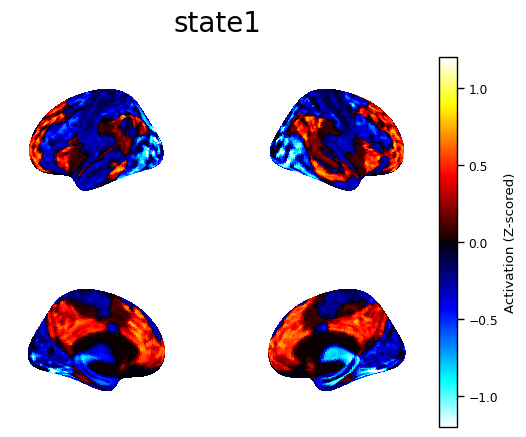

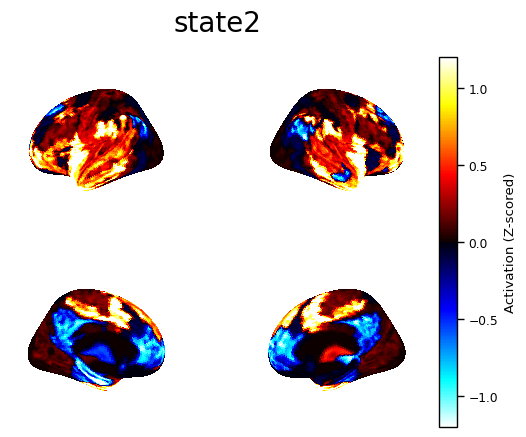

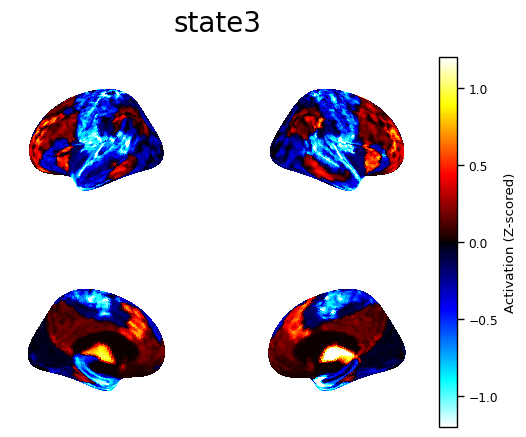

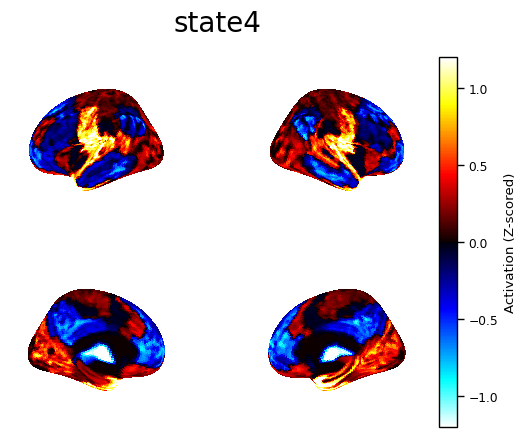

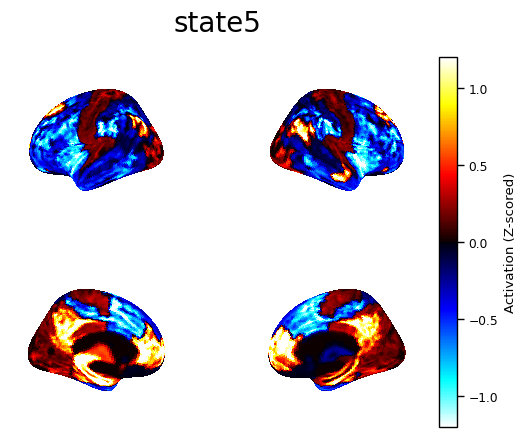

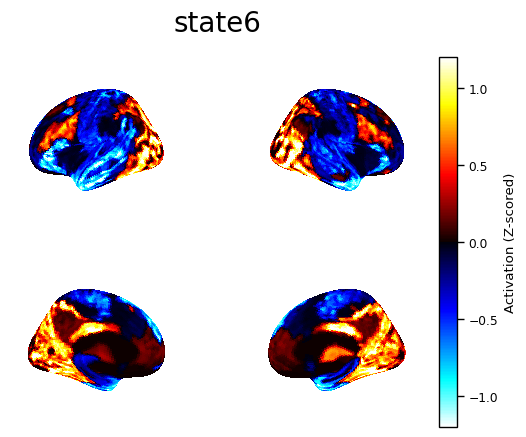

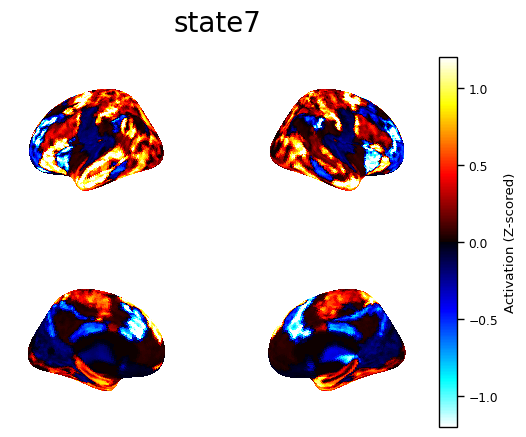

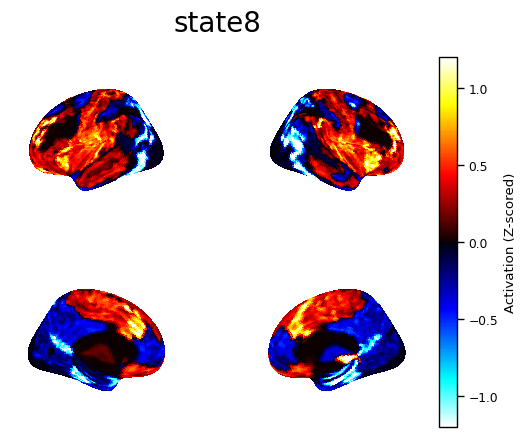

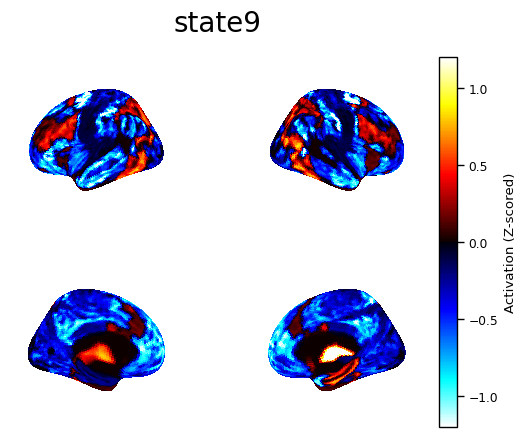

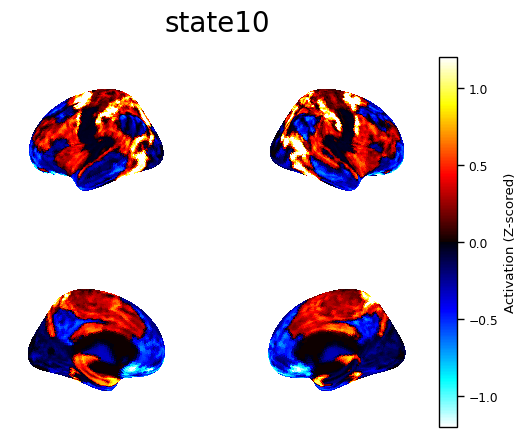

In [7]:
fsaverage = datasets.fetch_surf_fsaverage(mesh='fsaverage5')

tian_template = nib.load('input_data/Tian_Subcortex_S1_3T_2009cAsym.nii.gz')
yeo_template = nib.load('input_data/Yeo2011_17Networks_MNI152_FreeSurferConformed1mm.nii.gz')

yeo_resampled = resample_to_img(yeo_template, tian_template, interpolation='nearest')
yeo_data_resampled = yeo_resampled.get_fdata()
tian_data = tian_template.get_fdata()
affine = tian_template.affine

statename = ['state1', 'state2', 'state3','state4','state5','state6','state7','state8','state9','state10']

output_dir_tian = "output_HMM\Brain_state\output_states_tian"
output_dir_yeo = "output_HMM\Brain_state\output_states_yeo"

for stt in range(1, 11):  # 10 states
    # Load network
    tian_img = nib.load(os.path.join(output_dir_tian, f'state{stt}_tian_raw.nii.gz'))
    tian_data = tian_img.get_fdata()
    yeo_img = nib.load(os.path.join(output_dir_yeo, f'state{stt}_yeo_raw.nii.gz'))
    yeo_data = yeo_img.get_fdata()
    yeo_resampled_img = resample_to_img(yeo_img, tian_img, interpolation='nearest')
    yeo_data_resampled = np.squeeze(yeo_resampled_img.get_fdata())

    # Combine tian and yeo
    combined_data = tian_data + yeo_data_resampled

    combined_img = nib.Nifti1Image(combined_data, affine)

    surface_left = surface.vol_to_surf(combined_img, fsaverage.pial_left)
    surface_right = surface.vol_to_surf(combined_img, fsaverage.pial_right)

    sns.set_context('paper')
    fig, ((a, b), (c, d)) = plt.subplots(2, 2, subplot_kw={'projection': '3d'})

    plotting.plot_surf_stat_map(fsaverage.infl_left, surface_left, hemi='left',
                                view='lateral', bg_map=fsaverage.sulc_left, cmap='cold_hot',
                                vmax=1.2, symmetric_cbar=1, colorbar=False, axes=a)
    plotting.plot_surf_stat_map(fsaverage.infl_right, surface_right, hemi='right',
                                view='lateral', bg_map=fsaverage.sulc_right, cmap='cold_hot',
                                vmax=1.2, symmetric_cbar=1, colorbar=False, axes=b)
    plotting.plot_surf_stat_map(fsaverage.infl_left, surface_left, hemi='left',
                                view='medial', bg_map=fsaverage.sulc_left, cmap='cold_hot',
                                vmax=1.2, symmetric_cbar=1, colorbar=False, axes=c)
    plotting.plot_surf_stat_map(fsaverage.infl_right, surface_right, hemi='right',
                                view='medial', bg_map=fsaverage.sulc_right,  cmap='cold_hot',
                                vmax=1.2, symmetric_cbar=1, colorbar=False, axes=d)
    
    cbar = fig.colorbar(plt.cm.ScalarMappable(cmap='cold_hot', norm=plt.Normalize(vmin=-1.2, vmax=1.2)),
                    ax=[a, b, c, d], orientation='vertical', fraction=0.07, pad=0.04)
    cbar.set_label('Activation (Z-scored)')    

    plt.suptitle(statename[stt-1], fontsize=20)
    plt.show()


## Step 3: then graph covariance

In [8]:
data = sio.loadmat('output_HMM\Brain_state\covars.mat')
Covars = data['covars']  

Covariance matrices shape: (10, 33, 33)


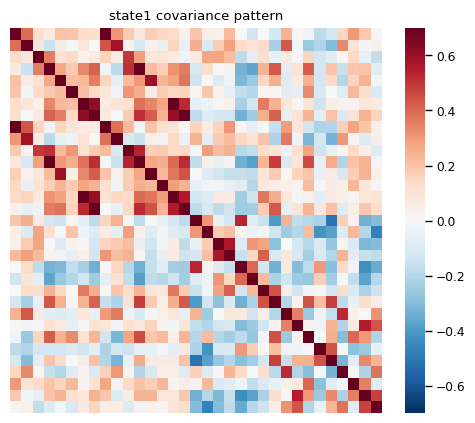

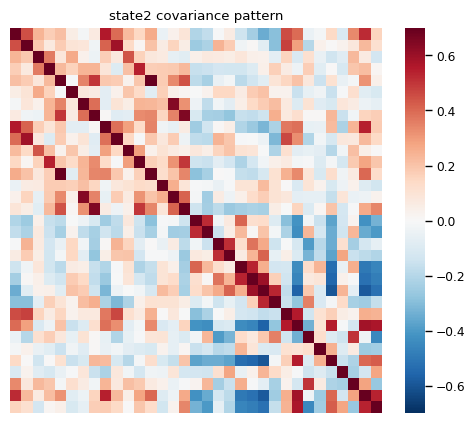

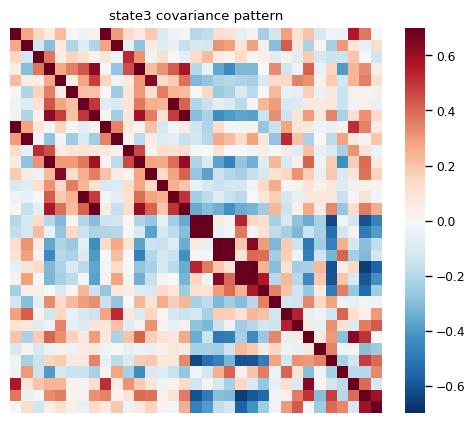

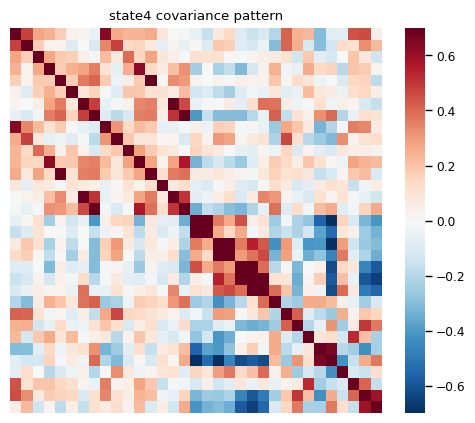

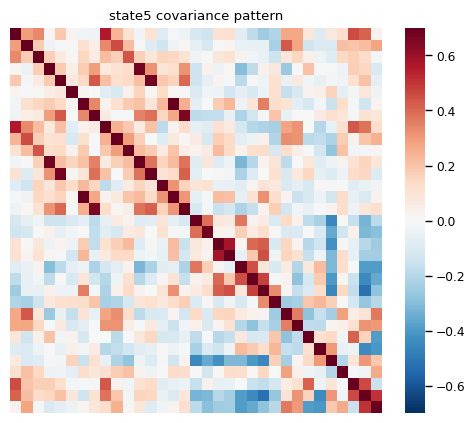

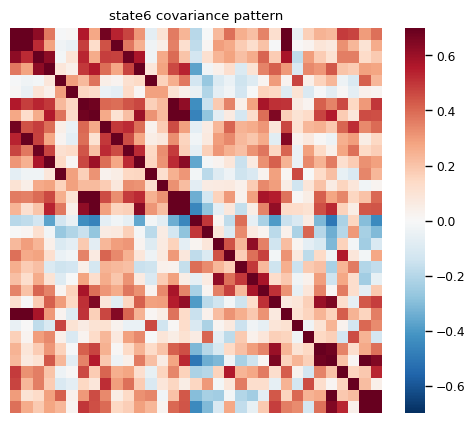

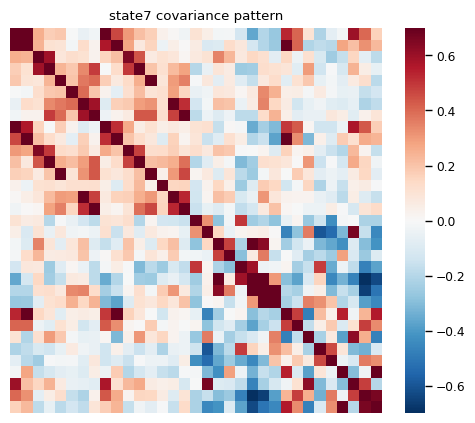

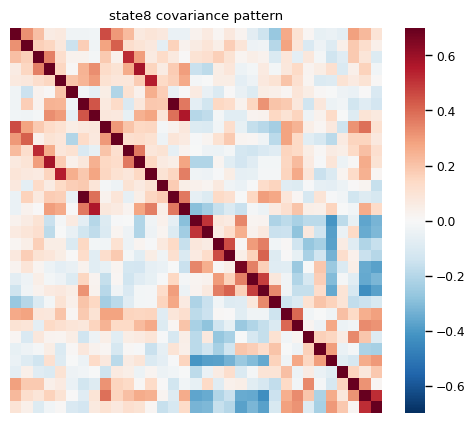

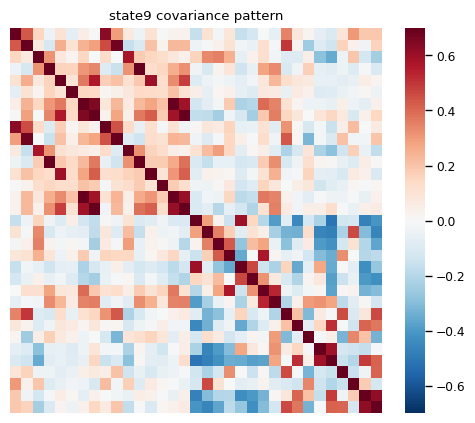

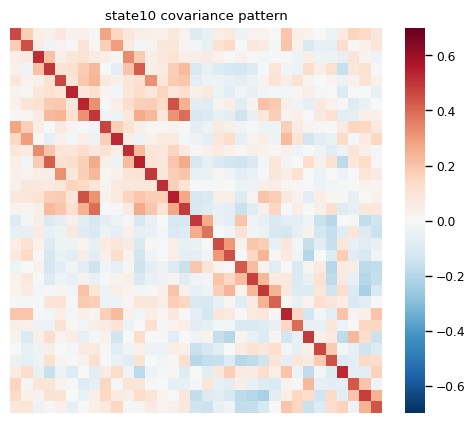

In [9]:
print("Covariance matrices shape:", Covars.shape)

state_names = ['state1', 'state2', 'state3','state4','state5','state6','state7','state8','state9','state10']

for i in range(Covars.shape[0]):
    cbar=True
    plt.figure(figsize=(6, 5))
    sns.heatmap(Covars[i], vmin=-0.7, vmax=0.7, cmap='RdBu_r', cbar=cbar, xticklabels=False, yticklabels=False)
    plt.title(f'{state_names[i]} covariance pattern')
    plt.show()
    